Import Libraries

In [387]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

Read Data

In [388]:
# =========================================
# READ DATA FROM EXCEL
# =========================================

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_R01.xlsx"   # ganti sesuai nama file Anda

# Generator data
gen_df = pd.read_excel(file_path, sheet_name="Gen")

# Demand data
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Jika data tidak diisi
gen_df['Droop'] = gen_df['Droop'].fillna(0.0)
gen_df['PFR_Fraction'] = gen_df['PFR_Fraction'].fillna(0.0)
gen_df['FreeGovernor'] = gen_df['FreeGovernor'].fillna(0).astype(int)

# Tampilkan untuk cek
#print(gen_df.head())
#print(demand_df.head())

Data Frame

In [389]:
# ============================
# CONVERT DATAFRAME → DICTIONARY
# ============================

# Set generator
G = gen_df['Unit'].tolist()

# Set time
T = demand_df['Hour'].tolist()

# Parameter generator
Pmin = dict(zip(gen_df['Unit'], gen_df['Pmin']))
Pmax = dict(zip(gen_df['Unit'], gen_df['Pmax']))
a = dict(zip(gen_df['Unit'], gen_df['a']))
b = dict(zip(gen_df['Unit'], gen_df['b']))
c = dict(zip(gen_df['Unit'], gen_df['c']))

SU_cost = dict(zip(gen_df['Unit'], gen_df['SU_Cost']))
SD_cost = dict(zip(gen_df['Unit'], gen_df['SD_Cost']))

RampUp = dict(zip(gen_df['Unit'], gen_df['Ramp_Up']))
RampDown = dict(zip(gen_df['Unit'], gen_df['Ramp_Down']))

MinUp = dict(zip(gen_df['Unit'], gen_df['Min_Up']))
MinDown = dict(zip(gen_df['Unit'], gen_df['Min_Down']))

# Demand
Demand = dict(zip(demand_df['Hour'], demand_df['Demand']))

# Frequency
Droop = dict(zip(gen_df['Unit'], gen_df['Droop']))
PFR_Fraction = dict(zip(gen_df['Unit'], gen_df['PFR_Fraction']))
FreeGovernor = dict(zip(gen_df['Unit'], gen_df['FreeGovernor']))

# Type
Type = dict(zip(gen_df['Unit'], gen_df['Type']))

# Parameter Turunan
PFR_Max = {g: PFR_Fraction[g] * Pmax[g] for g in gen_df['Unit']}

# Data Frekuensi
f0 = 50.0
f_min = 49.5
df_max = f0 - f_min

FreqBias = {}
for g in G:
    if Droop[g] > 0:
        FreqBias[g] = 1 / Droop[g]
    else:
        FreqBias[g] = 0

Definisi Model + Sets

In [390]:
model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

# ============================
# RESERVE REQUIREMENT
# ============================
#ReserveReq = {t: 0.10 * Demand[t] for t in Demand}

# ============================
# CONTINGENCY-BASED RESERVE
# ============================
Contingency = max(Pmax.values())   # kapasitas unit terbesar
ReserveReq = {t: Contingency for t in Demand}

print("Contingency adopted =", Contingency, "MW")

# kebutuhan total pfr
PFRReq = {t: 0.1 * Demand[t] for t in T}
print("PFR =",PFRReq,"??")


Contingency adopted = 300 MW
PFR = {1: 26.0, 2: 25.0, 3: 24.5, 4: 24.0, 5: 24.5, 6: 27.0, 7: 32.0, 8: 38.0, 9: 43.0, 10: 47.0, 11: 50.0, 12: 52.0, 13: 53.0, 14: 52.0, 15: 50.0, 16: 49.0, 17: 53.0, 18: 59.0, 19: 62.0, 20: 64.0, 21: 61.0, 22: 54.0, 23: 43.0, 24: 32.0} ??


Parameter Pyomo

In [391]:
model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

model.ReserveReq = Param(model.T, initialize=ReserveReq)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

model.PFRReq = Param(model.T, initialize=PFRReq)

model.delta_f_max = Param(initialize=df_max)

model.K_freq = Param(initialize=1000)

model.FreqBias = Param(model.G, initialize=FreqBias, within=NonNegativeReals)

Variables

In [392]:
# =====================
# Variables
# =====================
model.P = Var(model.G, model.T, domain=NonNegativeReals)
model.u = Var(model.G, model.T, domain=Binary)
model.y = Var(model.G, model.T, domain=Binary)              #startup
model.z = Var(model.G, model.T, within=Binary)              #shutdown
model.R = Var(model.G, model.T, within=NonNegativeReals)    #spinning reserve
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals) #model PFR
model.delta_f = Var(model.T, within=NonNegativeReals)            #deviasi frekuensi

Objective Function

In [393]:
# =========================================
# OBJECTIVE FUNCTION
# =========================================
def obj_rule(m):
    return sum(
        m.b[g] * m.P[g, t]              #Cost Koefisien b
        + m.c[g] * m.u[g, t]            #Cost Koefisien c
        + m.SU_cost[g] * m.y[g, t]      #Start Up Cost
        + m.SD_cost[g] * m.z[g, t]      #Shutdown Cost
        for g in m.G for t in m.T
    )

model.Obj = Objective(rule=obj_rule, sense=minimize)

Constraints

In [394]:
# =====================
# Constraints
# =====================

# Power balance
def balance_rule(m, t):
    return sum(m.P[g, t] for g in m.G) == m.Demand[t]

model.Balance = Constraint(model.T, rule=balance_rule)

# Capacity upper bound
def max_rule(m, g, t):
    return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

# Capacity lower bound
def min_rule(m, g, t):
    return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

model.MinCap = Constraint(model.G, model.T, rule=min_rule)

# Startup / Shutdown transition
def transition_rule(m, g, t):
    if t == 1:
        return m.u[g, t] == m.y[g, t] - m.z[g, t]
    else:
        return m.u[g, t] - m.u[g, t-1] == m.y[g, t] - m.z[g, t]

model.Transition = Constraint(model.G, model.T, rule=transition_rule)

# Ramp Up
def ramp_up_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t] - m.P[g, t-1] <= m.RampUp[g]

model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

# Ramp Down
def ramp_down_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t-1] - m.P[g, t] <= m.RampDown[g]

model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

# Minimum Up Time
def min_up_rule(m, g, t):
    MU = int(value(m.MinUp[g]))
    if t + MU - 1 > max(m.T):
        return Constraint.Skip
    return sum(m.u[g, k] for k in range(t, t + MU)) >= MU * m.y[g, t]

model.MinUpConstraint = Constraint(model.G, model.T, rule=min_up_rule)

# Minimum Down Time
def min_down_rule(m, g, t):
    MD = int(value(m.MinDown[g]))
    if t + MD - 1 > max(m.T):
        return Constraint.Skip
    return sum(1 - m.u[g, k] for k in range(t, t + MD)) >= MD * m.z[g, t]

model.MinDownConstraint = Constraint(model.G, model.T, rule=min_down_rule)

# Reserve per generator
def reserve_cap_rule(m, g, t):
    return m.P[g, t] + m.R[g, t] <= m.Pmax[g] * m.u[g, t]

model.ReserveCap = Constraint(model.G, model.T, rule=reserve_cap_rule)

# Reserve system
def system_reserve_rule(m, t):
    return sum(m.R[g, t] for g in m.G) >= m.ReserveReq[t]

model.SystemReserve = Constraint(model.T, rule=system_reserve_rule)

# PFR dibatasi headroom unit
def pfr_headroom_rule(m, g, t):
    return m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t] - m.P[g, t]

model.PFR_Headroom = Constraint(model.G, model.T, rule=pfr_headroom_rule)

# PFR dibatasi kemampuan unit dan status free governor
def pfr_cap_rule(m, g, t):
    return m.R_pfr[g, t] <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]

model.PFR_Cap = Constraint(model.G, model.T, rule=pfr_cap_rule)

# PFR harus bagian dari reserve total
def pfr_within_reserve_rule(m, g, t):
    return m.R_pfr[g, t] <= m.R[g, t]

model.PFR_Within_Reserve = Constraint(model.G, model.T, rule=pfr_within_reserve_rule)

def total_pfr_rule(m, t):
    return sum(m.R_pfr[g, t] for g in m.G) >= m.PFRReq[t]

model.TotalPFR = Constraint(model.T, rule=total_pfr_rule)

def freq_limit_rule(m, t):
    return m.delta_f[t] <= m.delta_f_max

model.FreqLimit = Constraint(model.T, rule=freq_limit_rule)

#def freq_response_rule(m, t):
#    return sum(m.R_pfr[g, t] / m.Droop[g]
#               for g in m.G if m.Droop[g] > 0) >= m.delta_f[t] * m.K_freq

#model.FreqResponse = Constraint(model.T, rule=freq_response_rule)

#def pfr_droop_rule(m, g, t):
#    return m.R_pfr[g, t] <= m.FreqBias[g] * m.delta_f[t]

#model.PFR_Droop = Constraint(model.G, model.T, rule=pfr_droop_rule)

Solve

In [395]:
# =========================================
# Solve
# =========================================
from pyomo.opt import SolverStatus, TerminationCondition

solver = SolverFactory('cbc')
results = solver.solve(model, tee=False)

if (results.solver.status == SolverStatus.ok and
    results.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")

Optimal solution found.


Results


========== TABEL A: DISPATCH ==========
Keterangan: Output daya tiap unit dan keseimbangan sistem (harus = Demand)

 Hour  Demand  G1_P  G2_P  G3_P  G4_P  G5_P  G6_P  G7_P  Total_Power
    1     260    80     0    20     0     0    70    90          260
    2     250    80     0    20     0     0   120    30          250
    3     245    80     0    20     0     0    55    90          245
    4     240    80     0    20     0     0    50    90          240
    5     245    80     0    20     0     0   120    25          245
    6     270    80     0    20     0     0    80    90          270
    7     320    80     0     0   100     0   120    20          320
    8     380    80     0     0   100     0   110    90          380
    9     430   120     0     0   100     0   120    90          430
   10     470   130     0     0   100    30   120    90          470
   11     500   160     0     0   100    30   120    90          500
   12     520   180     0     0   100    30   120    90

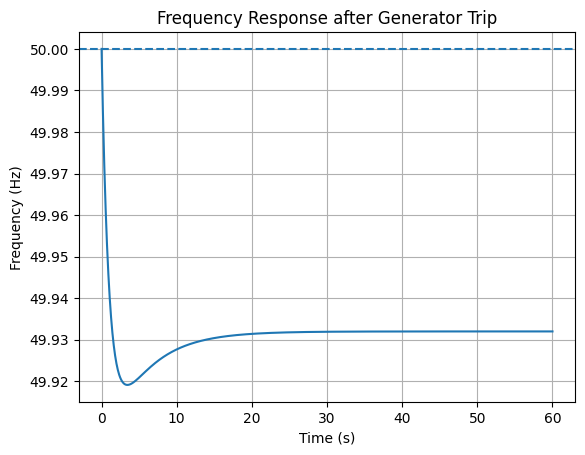

In [ ]:
# =====================
# Format
# =====================
def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    else:
        return round(x, 2)
    
# =====================
# Print Results
# =====================
#print("Total System Cost =", fmt(value(model.Obj)))
from pyomo.environ import value
import pandas as pd

rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    total_reserve = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])
        
        r = value(model.R[g, t])
        r_pfr = value(model.R_pfr[g, t])

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)

        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)

        total_power += p
        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])

        # jika reserve aktif
        if hasattr(model, "R"):
            r = value(model.R[g, t])
            row[f"{g}_R"] = fmt(r)
            total_reserve += r

    row["Total_Power"] = fmt(total_power)
    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Total Cost"] = fmt(fuel_cost + fixed_cost + startup_cost + shutdown_cost)

    if hasattr(model, "ReserveReq") and hasattr(model, "R"):
        reserve_req = value(model.ReserveReq[t])
        row["Total_Reserve"] = fmt(total_reserve)
        row["Reserve_Req"] = fmt(reserve_req)
        row["Reserve_Margin"] = fmt(total_reserve - reserve_req)

    total_pfr = sum(value(model.R_pfr[g, t]) for g in model.G)
    row["Total_PFR"] = fmt(total_pfr)
    row["PFR_Req"] = fmt(value(model.PFRReq[t]))
    row["PFR_Margin"] = fmt(total_pfr - value(model.PFRReq[t]))

    rows.append(row)

df_hourly = pd.DataFrame(rows)

# ==========================================================
print("\n========== TABEL A: DISPATCH ==========")
print("Keterangan: Output daya tiap unit dan keseimbangan sistem (harus = Demand)\n")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL B: STATUS UNIT ==========")
print("Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)\n")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))

# ==========================================================
if "Reserve_Req" in df_hourly.columns:
    print("\n========== TABEL C: RESERVE ==========")
    print("Keterangan: Cadangan daya (spinning reserve) dan margin sistem\n")

    reserve_cols = ["Hour", "Reserve_Req"] + [f"{g}_R" for g in model.G] + ["Total_Reserve", "Reserve_Margin"]
    print(df_hourly[reserve_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL D: BIAYA ==========")
print("Keterangan: Komponen biaya pembangkitan per jam\n")

cost_cols = ["Hour", "Fuel Cost", "Fixed Cost", "Startup Cost", "Shutdown Cost", "Total Cost"]
print(df_hourly[cost_cols].to_string(index=False))

# ==========================================================
print("\n========== TABEL E: RAMPING ==========")
print("Keterangan: Perubahan daya antar jam (ΔP)\n")

# ==========================================================
print("\n========== TABEL PFR ==========")
print("Keterangan: Primary Frequency Reserve per unit dan margin sistem\n")

pfr_cols = ["Hour", "PFR_Req"] + [f"{g}_PFR" for g in model.G] + ["Total_PFR", "PFR_Margin"]
print(df_hourly[pfr_cols].to_string(index=False))

#====================================================
selected_hour = 5

df_t = df_hourly[df_hourly["Hour"] == selected_hour].copy()

print("Snapshot jam =", selected_hour)
print(df_t.to_string(index=False))

gen_list = list(model.G)

dispatch_at_t = {}

for g in gen_list:
    p = float(df_t[f"{g}_P"].iloc[0])
    u = float(df_t[f"{g}_U"].iloc[0])

    if u > 0.5 and p > 0:
        dispatch_at_t[g] = p

print("Dispatch unit ON pada jam", selected_hour, ":", dispatch_at_t)

trip_unit = max(dispatch_at_t, key=dispatch_at_t.get)
P_loss = dispatch_at_t[trip_unit]

print("Unit yang trip =", trip_unit)
print("Daya hilang =", P_loss, "MW")

# ========================================================

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}
    if t == 1:
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))

# ==========================================================
print("\n========== TABEL F: SYSTEM SUMMARY ==========")
print("Keterangan: Ringkasan performa sistem\n")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
]

if "Reserve_Margin" in df_hourly.columns:
    summary_rows.append(["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())])

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows.append(["Total Startup Events", fmt(total_startup)])
summary_rows.append(["Total Shutdown Events", fmt(total_shutdown)])

df_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_summary.to_string(index=False))


import numpy as np
import matplotlib.pyplot as plt

# parameter dasar
f0 = 50  # Hz
P_loss = float(dispatch_at_t[trip_unit])  # MW
H_sys = 5 # asumsi inersia sistem (detik)

# ambil PFR dari unit yang tidak trip
total_pfr = 0
for g in gen_list:
    if g != trip_unit:
        total_pfr += float(df_t[f"{g}_PFR"].iloc[0])

print("Total PFR =", total_pfr, "MW")

t = np.linspace(0, 60, 1000)

#===========================
# Respon Governor
#===========================
tau_gov = 3 # konstanta waktu governor (detik)
P_response = total_pfr * (1 - np.exp(-t / tau_gov))

#===============================
# Deviasi Frekuensi
#===============================
delta_f = (P_loss - P_response) / (2 * H_sys * 1000)
freq_response = f0 - delta_f


#=========================================
# Indikator Hasil
#==========================================
f_nadir = np.min(freq_response)
print("Frequency nadir =", round(f_nadir, 4), "Hz")

f_ss = freq_response[-1]
print("Steady-state frequency =", round(f_ss, 4), "Hz")

f_min = 49.5

if f_nadir >= f_min:
    print("Status: AMAN")
else:
    print("Status: TIDAK AMAN")

# waktu simulasi (detik)
print(freq_response[:5])

# model sederhana respon frekuensi
# drop cepat lalu recovery lambat
tau1 = 1   # waktu drop
tau2 = 5   # waktu recovery

delta_f_drop = (P_loss / 1000) * (1 - np.exp(-t / tau1))
delta_f_recovery = (total_pfr / 1000) * (1 - np.exp(-t / tau2))

# frekuensi sistem
f = f0 - delta_f_drop + delta_f_recovery
#================================
#Hasil
#================================
# =========================
# REKAP HASIL PER JAM
# =========================
summary = []

# contoh jam yang ingin diuji
test_hours = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

for th in test_hours:
    
    # ambil snapshot jam
    df_t = df_hourly[df_hourly["Hour"] == th].copy()
    
    # unit ON
    dispatch = {g: float(df_t[f"{g}_P"].iloc[0]) for g in gen_list if float(df_t[f"{g}_P"].iloc[0]) > 0}
    
    # tentukan unit trip (largest)
    trip_unit = max(dispatch, key=dispatch.get)
    P_loss = dispatch[trip_unit]
    
    # total reserve
    total_reserve = sum(float(df_t[f"{g}_R"].iloc[0]) for g in gen_list)
    
    # total PFR (kecuali unit trip)
    total_pfr = 0.0
    for g in gen_list:
        if g != trip_unit:
            total_pfr += float(df_t[f"{g}_PFR"].iloc[0])
    
    # =========================
    # SIMULASI FREKUENSI
    # =========================
    f0 = 50
    H_sys = 5
    
    t = np.linspace(0, 60, 1000)
    
    tau1 = 1
    tau2 = 5
    
    delta_f_drop = (P_loss / 1000) * (1 - np.exp(-t / tau1))
    delta_f_recovery = (total_pfr / 1000) * (1 - np.exp(-t / tau2))
    
    f = f0 - delta_f_drop + delta_f_recovery
    
    # indikator
    f_nadir = np.min(f)
    f_ss = f[-1]
    
    # simpan ke tabel
    summary.append([
        th,
        trip_unit,
        round(P_loss, 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(f_nadir, 4),
        round(f_ss, 4)
    ])

# =========================
# TAMPILKAN TABEL
# =========================
import pandas as pd

df_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print(df_summary.to_string(index=False))

#============================================
# plot
plt.figure()
plt.plot(t, f)
plt.axhline(50, linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency Response after Generator Trip")
plt.grid()
plt.show()

Grafik

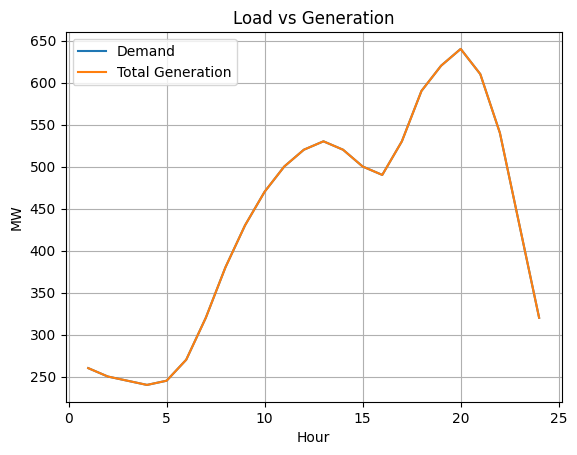

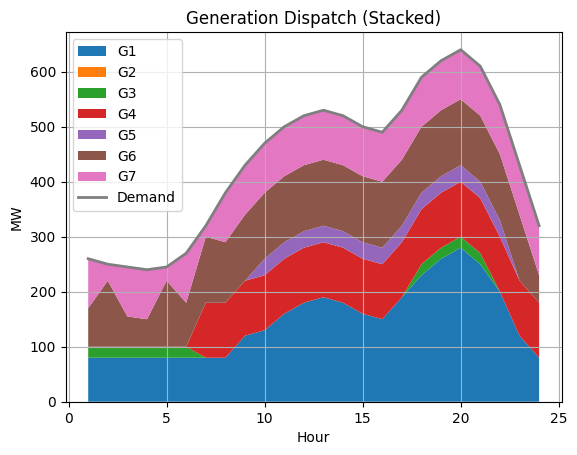

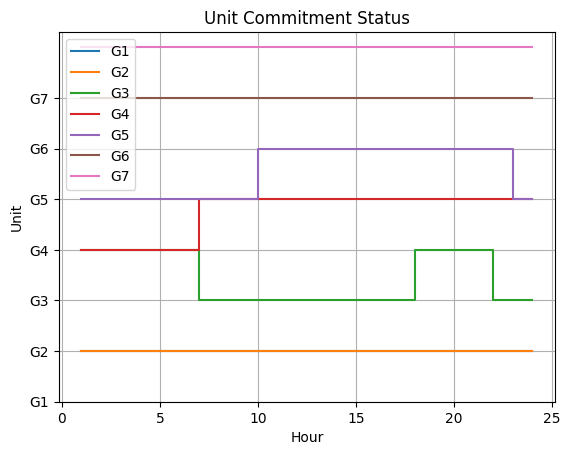

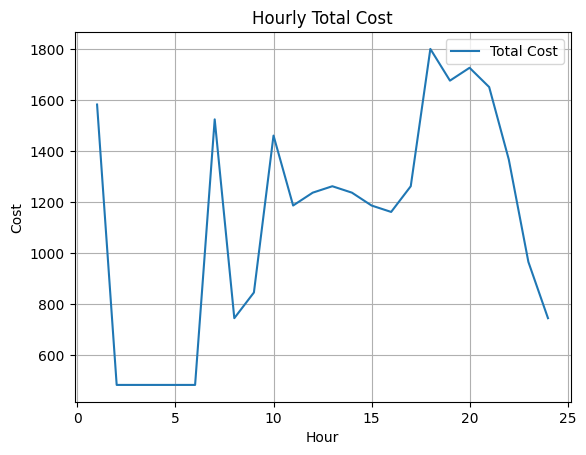

In [397]:
import matplotlib.pyplot as plt
# Mapping nama unit untuk tampilan
name_map = {
    "G1": "G1",
    "G2": "G2",
    "G3": "G3",
    "G4": "G4",
    "G5": "G5",
    "G6": "G6",
    "G7": "G7"
}

# Label Legend
plot_labels = [name_map.get(g, g) for g in model.G]

# ===============================
# 1. LOAD vs GENERATION
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Demand"], label="Demand")
plt.plot(df_hourly["Hour"], df_hourly["Total_Power"], label="Total Generation")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Load vs Generation")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 2. DISPATCH PER UNIT (STACKED)
# ===============================
gen_cols = [f"{g}_P" for g in model.G]



plt.figure()
plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

# Overlay demand
plt.plot(df_hourly["Hour"], df_hourly["Demand"], linewidth=2, label="Demand")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# 3. STATUS UNIT (ON/OFF)
# ===============================
plt.figure()

for i, g in enumerate(model.G):
    plt.step(
        df_hourly["Hour"],
        df_hourly[f"{g}_U"] + i,   # offset biar tidak numpuk
        where='post',
        label=name_map.get(g,g)
    )

plt.xlabel("Hour")
plt.ylabel("Unit")
plt.title("Unit Commitment Status")
plt.yticks(range(len(model.G)), model.G)
plt.legend()
plt.grid()
plt.show()


# ===============================
# 4. TOTAL COST PER HOUR
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Total Cost"], label="Total Cost")

plt.xlabel("Hour")
plt.ylabel("Cost")
plt.title("Hourly Total Cost")
plt.legend()
plt.grid()
plt.show()